<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-assignment-10-Ak/blob/main/Assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)


In [1]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest

# TODO: Import necessary libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# TODO: Load the dataset
# Update this path to where your amazon_alexa.tsv file is saved in your Drive
file_path = '/content/amazon_alexa.tsv'
df = pd.read_csv(file_path, sep='\t')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_10133/2669120836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='feedback', data=df, palette='Set2')


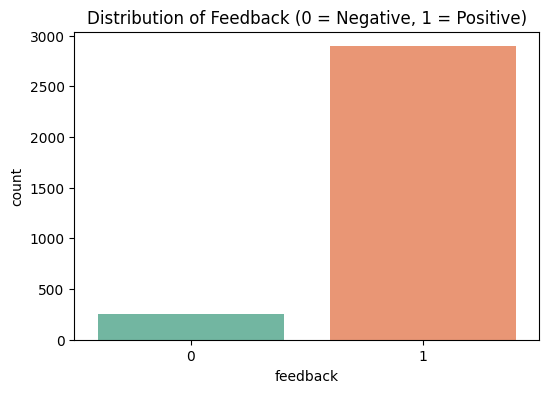

In [7]:
# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
plt.figure(figsize=(6, 4))
sns.countplot(x='feedback', data=df, palette='Set2')
plt.title('Distribution of Feedback (0 = Negative, 1 = Positive)')
plt.show()

/tmp/ipykernel_10133/3215988171.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='variation', data=df, errorbar=None, palette='viridis')


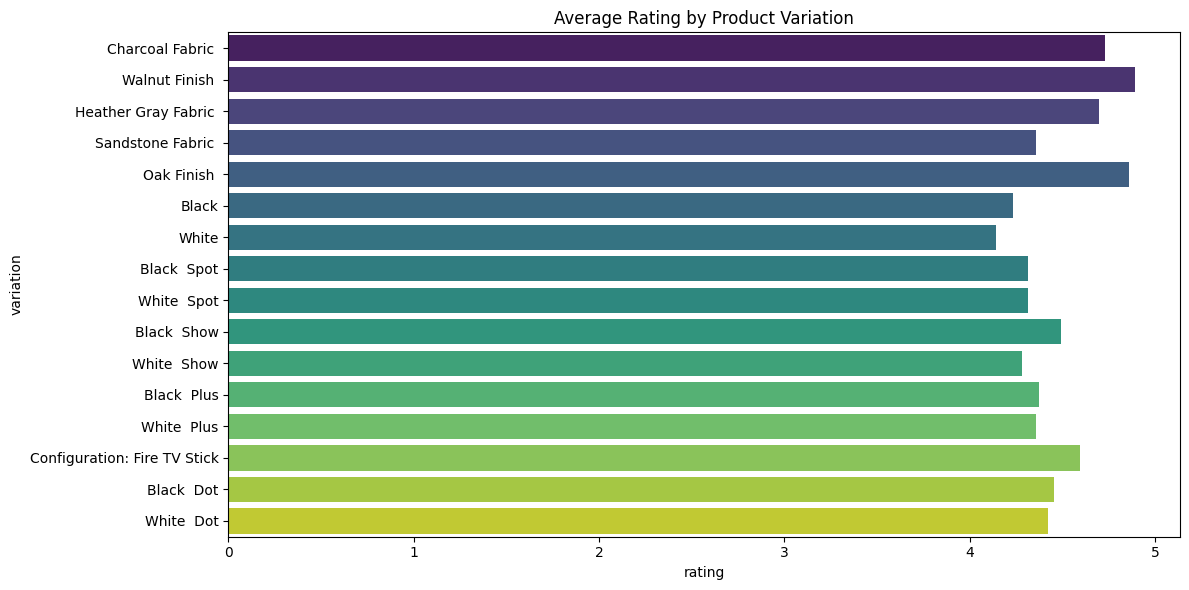

In [8]:
# TODO: Visualize the relationship between variations and ratings
plt.figure(figsize=(12, 6))
sns.barplot(x='rating', y='variation', data=df, errorbar=None, palette='viridis')
plt.title('Average Rating by Product Variation')
plt.tight_layout()
plt.show()


In [9]:
# TODO: Drop irrelevant columns
df_cleaned = df.drop(columns=['date', 'rating'])

In [10]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
variation_dummies = pd.get_dummies(df_cleaned['variation'], drop_first=True)

In [11]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Filling missing reviews with empty space just in case
df_cleaned['verified_reviews'] = df_cleaned['verified_reviews'].fillna('')

vectorizer = CountVectorizer(stop_words='english', max_features=2500)
X_text = vectorizer.fit_transform(df_cleaned['verified_reviews'])
X_text_df = pd.DataFrame(X_text.toarray(), columns=vectorizer.get_feature_names_out())

In [12]:
# TODO: Combine tokenized reviews with the main dataframe
# Drop original columns we transformed to prevent duplication
df_cleaned = df_cleaned.drop(columns=['variation', 'verified_reviews'])
X_final = pd.concat([df_cleaned.drop(columns=['feedback']), variation_dummies, X_text_df], axis=1)
X_final.columns = X_final.columns.astype(str) # Ensure all features have string names

In [13]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
X = X_final
y = df['feedback']

# TODO: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the Random Forest model
# TODO: Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

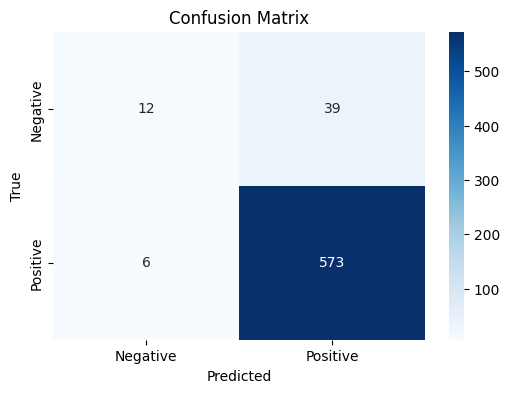

In [15]:
# TODO: Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
# TODO: Print classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.67      0.24      0.35        51
           1       0.94      0.99      0.96       579

    accuracy                           0.93       630
   macro avg       0.80      0.61      0.66       630
weighted avg       0.91      0.93      0.91       630



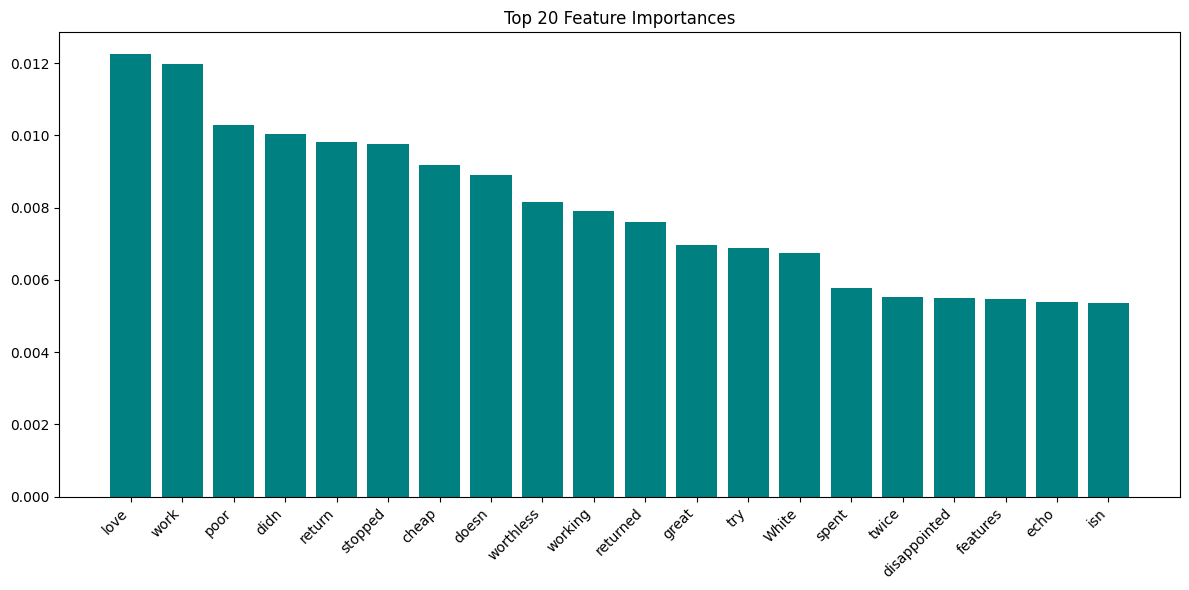

In [17]:
# Feature Importance
# TODO: Visualize feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top 20 features
plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices[:20]], align="center", color='teal')
plt.xticks(range(20), [X.columns[i] for i in indices[:20]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# TODO: Make predictions on new data
def predict_sentiment(new_review):
    # Vectorize text features using the pre-trained vectorizer
    text_vectorized = vectorizer.transform([new_review]).toarray()
    text_df = pd.DataFrame(text_vectorized, columns=vectorizer.get_feature_names_out())

    # Create an empty template mirroring structural features (dummies)
    dummy_features = pd.DataFrame(0, index=[0], columns=variation_dummies.columns)

    # Combine mock features to replicate input shape
    full_sample = pd.concat([dummy_features, text_df], axis=1)
    full_sample.columns = full_sample.columns.astype(str)

    # Run structural prediction
    prediction = rf_model.predict(full_sample)[0]
    return "Positive" if prediction == 1 else "Negative"

# Example usage of your prediction function:
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")

The sentiment of the new review is: Positive
